# Online Retail II - Exploratory Data Analysis

## Project Objective

The main objective of this project is to perform a comprehensive Exploratory Data Analysis (EDA) on the 'Online Retail II' dataset. This analysis aims to understand the sales patterns, customer behavior, and product performance within the retail business. The insights gained will help in making data-driven decisions for business growth, marketing strategies, and inventory management.

## Business Questions

Our EDA will focus on answering the following key business questions:

1.  What are the overall sales trends over time (monthly, daily, hourly)?
2.  Which products are the top-sellers and top-revenue generators?
3.  Which countries contribute the most to sales and customer base?
4.  What are the characteristics of high-value customers?
5.  How do returns and cancellations impact overall sales?
6.  What are the key performance indicators (KPIs) of the business, such as Average Order Value (AOV) and basket size?
7.  Are there any significant outliers or anomalies in the data that need further investigation?
8.  Can we identify any potential for customer segmentation or targeted marketing efforts?

## Data Dictionary

The dataset contains the following columns:

| Column Name   | Description                                                                 | Data Type |
| :------------ | :-------------------------------------------------------------------------- | :-------- |
| `Invoice`     | Invoice number. A 6-digit integral number uniquely assigned to each transaction. If this code starts with 'C', it indicates a cancellation. | `object`  |
| `StockCode`   | Product (item) code. A 5-digit integral number uniquely assigned to each distinct product. | `object`  |
| `Description` | Product (item) name.                                                        | `object`  |
| `Quantity`    | The quantity of each product (item) per transaction. If negative, it indicates a return. | `int64`   |
| `InvoiceDate` | Invoice date and time. The day and time when each transaction was generated. | `datetime`|
| `Price`       | Unit price. Product price per unit in sterling (£).                         | `float64` |
| `Customer ID` | Customer number. A 5-digit integral number uniquely assigned to each customer. | `float64` |
| `Country`     | Country name. The name of the country where each customer resides.          | `object`  |


## Setup and Data Loading

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Loading the dataset
file_path = '/content/online_retail_II.xlsx'
df = pd.read_excel(file_path)
print("Data loaded successfully. Displaying the first 5 rows:")
display(df.head())

Data loaded successfully. Displaying the first 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [30]:
#Shape of the Dataset
df.shape

(400916, 14)

In [16]:
# Display basic information about the DataFrame
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [17]:
# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


Next, we'll check for duplicate rows in the dataset.

In [18]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    print("Dropping duplicate rows...")
    df.drop_duplicates(inplace=True)
    print(f"Number of rows after dropping duplicates: {df.shape[0]}")

Number of duplicate rows: 6865
Dropping duplicate rows...
Number of rows after dropping duplicates: 518596


### Handling Missing Values



In [31]:
# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())
print("\nPercentage of missing values per column:")
display(df.isnull().sum() / len(df) * 100)
df['Description'].fillna('Unknown Product', inplace=True)
print("\nDropping rows with missing Customer ID...")
df.dropna(subset=['Customer ID'], inplace=True)
print(f"Number of rows after dropping missing Customer ID: {df.shape[0]}")


Missing values per column:


,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0
TotalPrice,0
InvoiceYear,0



Percentage of missing values per column:


,0
Invoice,0.0
StockCode,0.0
Description,0.0
Quantity,0.0
InvoiceDate,0.0
Price,0.0
Customer ID,0.0
Country,0.0
TotalPrice,0.0
InvoiceYear,0.0



Dropping rows with missing Customer ID...
Number of rows after dropping missing Customer ID: 400916


/tmp/ipykernel_3942/2675608364.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Description'].fillna('Unknown Product', inplace=True)


### Handling Negative Quantities and Prices

The `df.describe()` output showed negative values for `Quantity` and `Price`. Negative quantities usually indicate returns, while negative prices might be errors or specific return policies. For initial EDA, we'll focus on actual sales. Let's filter out rows where `Quantity` or `Price` are zero or negative.

In [20]:
# Filter out rows with negative or zero Quantity and Price
print("\nFiltering out rows with Quantity <= 0 or Price <= 0...")
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
print(f"Number of rows after filtering: {df.shape[0]}")


Filtering out rows with Quantity <= 0 or Price <= 0...
Number of rows after filtering: 400916


### Feature Engineering: Total Price

Let's create a 'TotalPrice' column, which is often useful for sales analysis.

In [21]:
# Create a 'TotalPrice' column
df['TotalPrice'] = df['Quantity'] * df['Price']
print("\n'TotalPrice' column created. Displaying head with new column:")
display(df.head())


'TotalPrice' column created. Displaying head with new column:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


### Univariate Analysis: Numerical Features

Let's visualize the distribution of `Quantity`, `Price`, and `TotalPrice` using histograms and box plots.

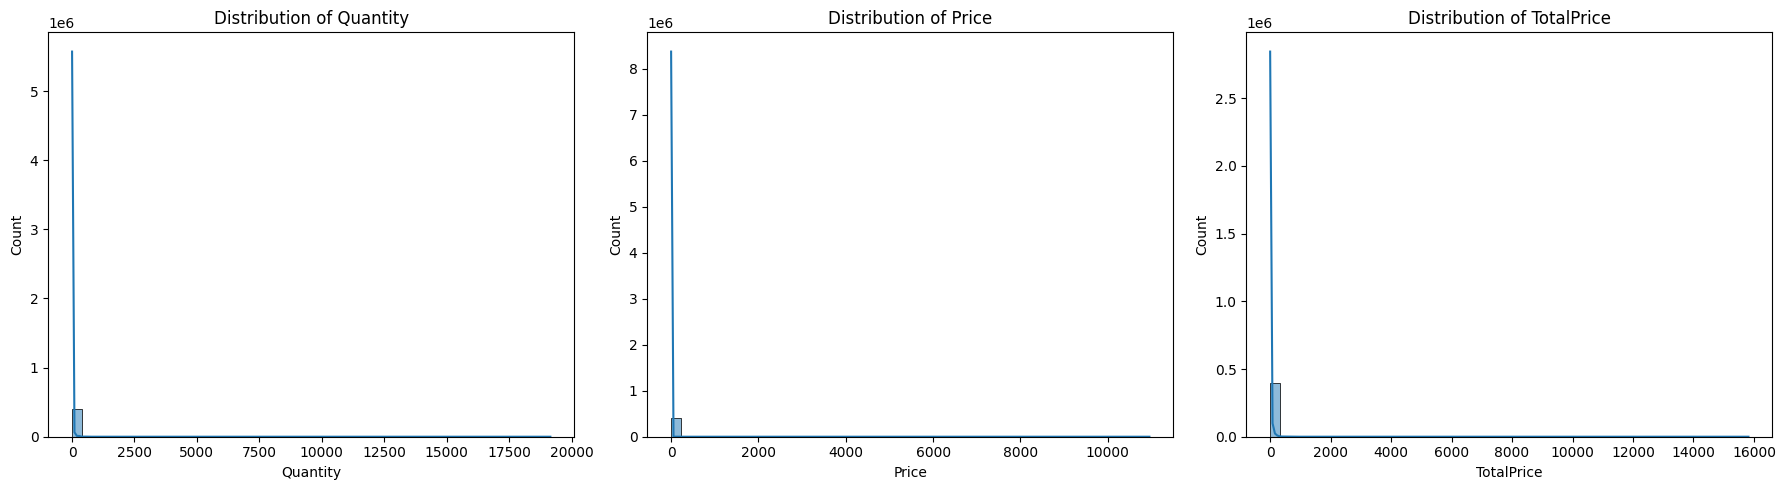

In [22]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['Quantity'], bins=50, kde=True)
plt.title('Distribution of Quantity')

plt.subplot(1, 3, 2)
sns.histplot(df['Price'], bins=50, kde=True)
plt.title('Distribution of Price')

plt.subplot(1, 3, 3)
sns.histplot(df['TotalPrice'], bins=50, kde=True)
plt.title('Distribution of TotalPrice')

plt.tight_layout()
plt.show()

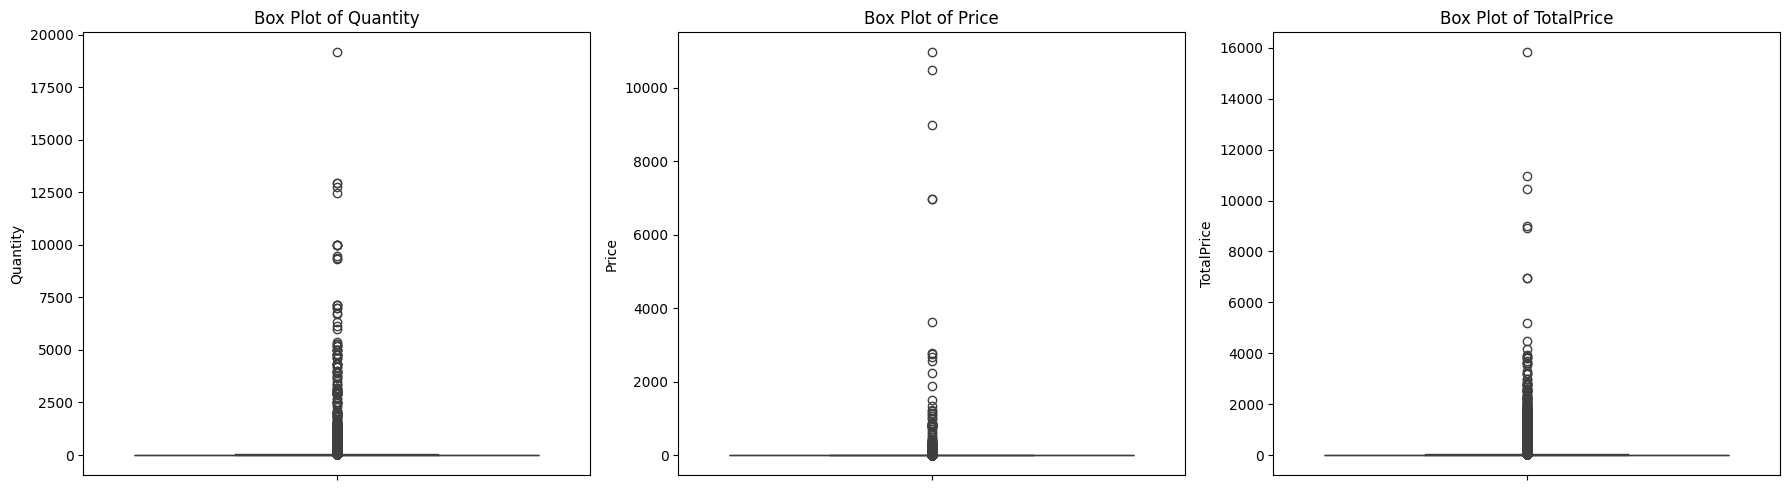

In [23]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['Quantity'])
plt.title('Box Plot of Quantity')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['Price'])
plt.title('Box Plot of Price')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['TotalPrice'])
plt.title('Box Plot of TotalPrice')

plt.tight_layout()
plt.show()

The histograms and box plots reveal highly skewed distributions for 'Quantity', 'Price', and 'TotalPrice', with a large concentration of values at the lower end and many outliers extending to the higher end. This is common in sales data where a few transactions involve very high quantities, prices, or total values.

### Univariate Analysis: Categorical Features

Now, let's explore the categorical columns, starting with 'Country' and 'StockCode', to understand their frequency distributions.

/tmp/ipykernel_3942/2199201726.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Country'], order=df['Country'].value_counts().index[:10], palette='viridis')


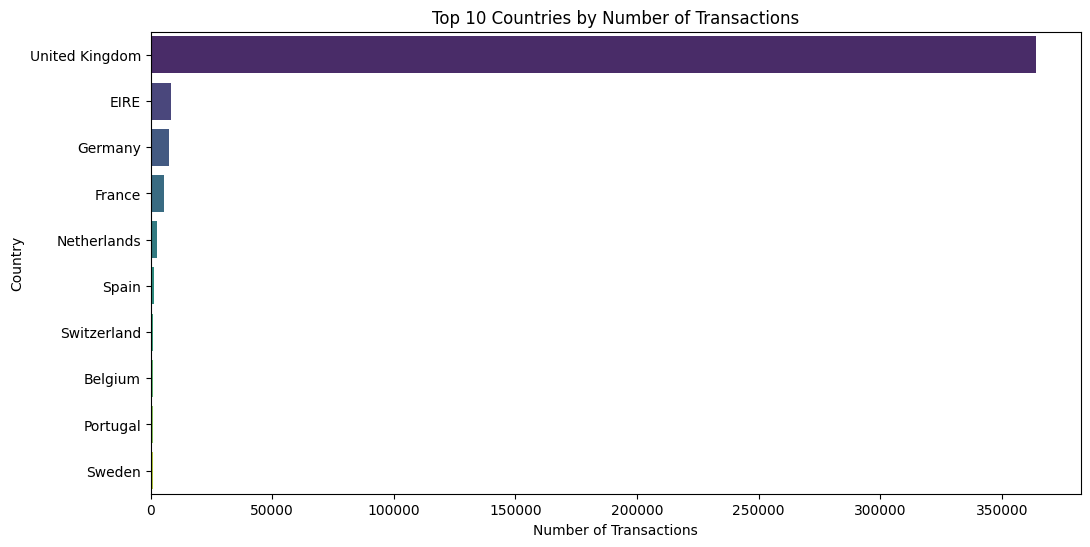

/tmp/ipykernel_3942/2199201726.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['StockCode'], order=df['StockCode'].value_counts().index[:10], palette='magma')


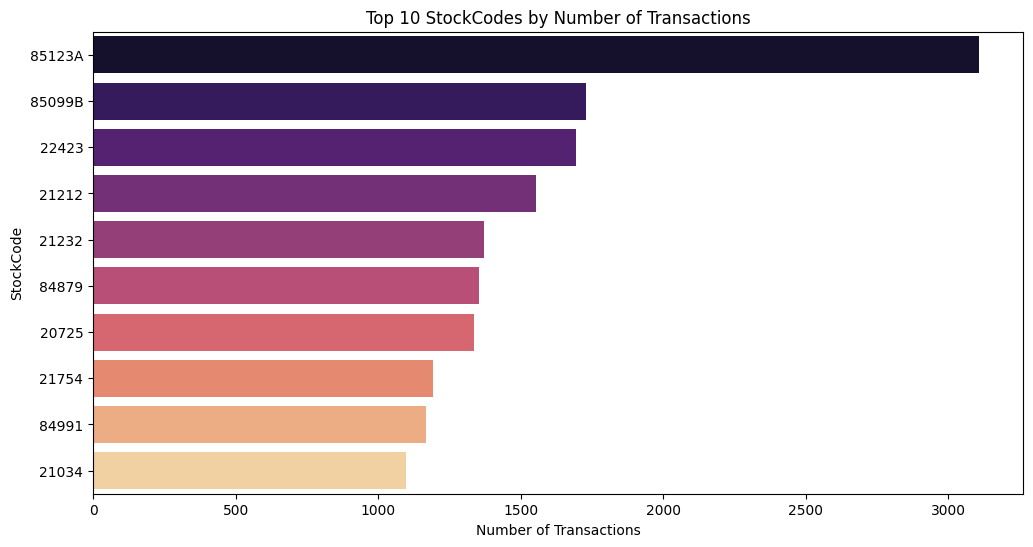

In [24]:
# Top 10 Countries by number of transactions
plt.figure(figsize=(12, 6))
sns.countplot(y=df['Country'], order=df['Country'].value_counts().index[:10], palette='viridis')
plt.title('Top 10 Countries by Number of Transactions')
plt.xlabel('Number of Transactions')
plt.ylabel('Country')
plt.show()

# Top 10 StockCodes (products) by number of transactions
plt.figure(figsize=(12, 6))
sns.countplot(y=df['StockCode'], order=df['StockCode'].value_counts().index[:10], palette='magma')
plt.title('Top 10 StockCodes by Number of Transactions')
plt.xlabel('Number of Transactions')
plt.ylabel('StockCode')
plt.show()

### Time Series Analysis: Sales Trends

Let's extract features from `InvoiceDate` to understand sales trends over time.

In [25]:
# Extract time-based features
df['InvoiceYear'] = df['InvoiceDate'].dt.year
df['InvoiceMonth'] = df['InvoiceDate'].dt.month
df['InvoiceDay'] = df['InvoiceDate'].dt.day
df['InvoiceHour'] = df['InvoiceDate'].dt.hour
df['InvoiceDayOfWeek'] = df['InvoiceDate'].dt.dayofweek # Monday=0, Sunday=6

print("Time-based features extracted. Displaying head with new columns:")
display(df.head())

Time-based features extracted. Displaying head with new columns:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,InvoiceYear,InvoiceMonth,InvoiceDay,InvoiceHour,InvoiceDayOfWeek
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1,7,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,7,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,7,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1,7,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1,7,1


Now, let's visualize sales trends by month, day of the week, and hour.

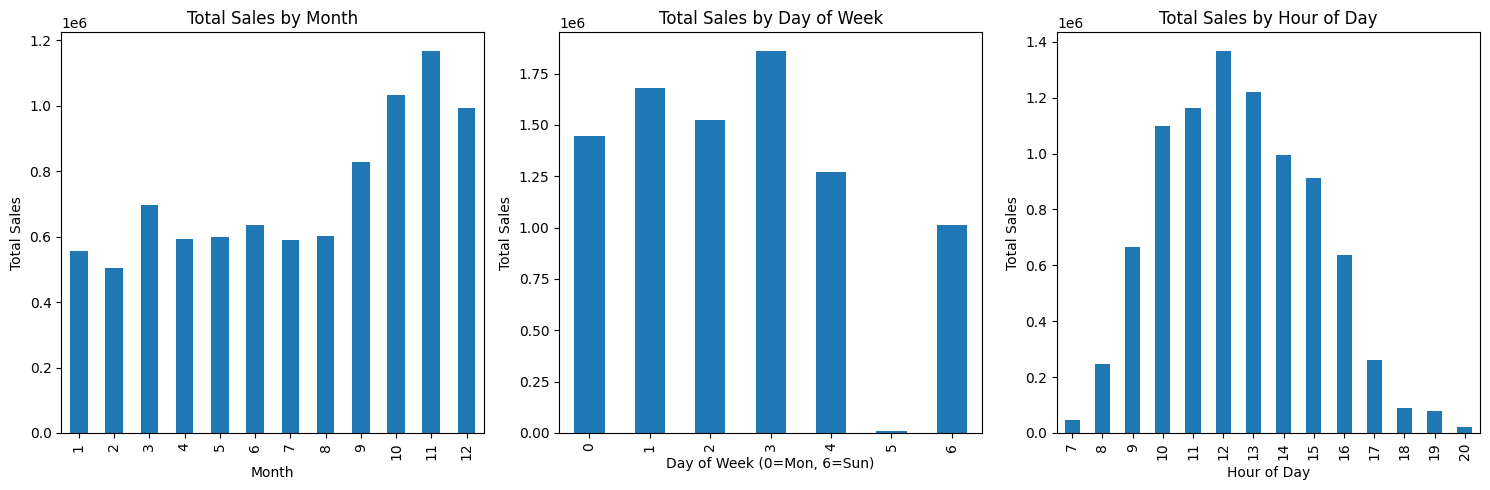

In [26]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
df.groupby('InvoiceMonth')['TotalPrice'].sum().plot(kind='bar')
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.subplot(1, 3, 2)
df.groupby('InvoiceDayOfWeek')['TotalPrice'].sum().plot(kind='bar')
plt.title('Total Sales by Day of Week')
plt.xlabel('Day of Week (0=Mon, 6=Sun)')
plt.ylabel('Total Sales')

plt.subplot(1, 3, 3)
df.groupby('InvoiceHour')['TotalPrice'].sum().plot(kind='bar')
plt.title('Total Sales by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

### Bivariate Analysis

Let's explore relationships between different variables. We'll start by looking at total sales by country and top-selling products.

/tmp/ipykernel_3942/1508520202.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries_sales.values, y=top_countries_sales.index, palette='viridis')


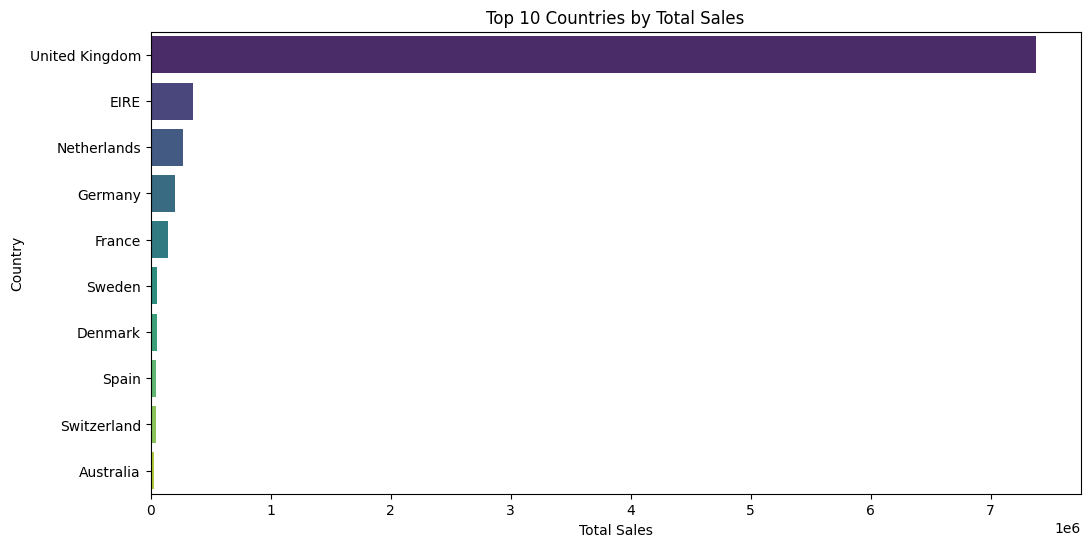

/tmp/ipykernel_3942/1508520202.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products_sales.values, y=top_products_sales.index, palette='magma')


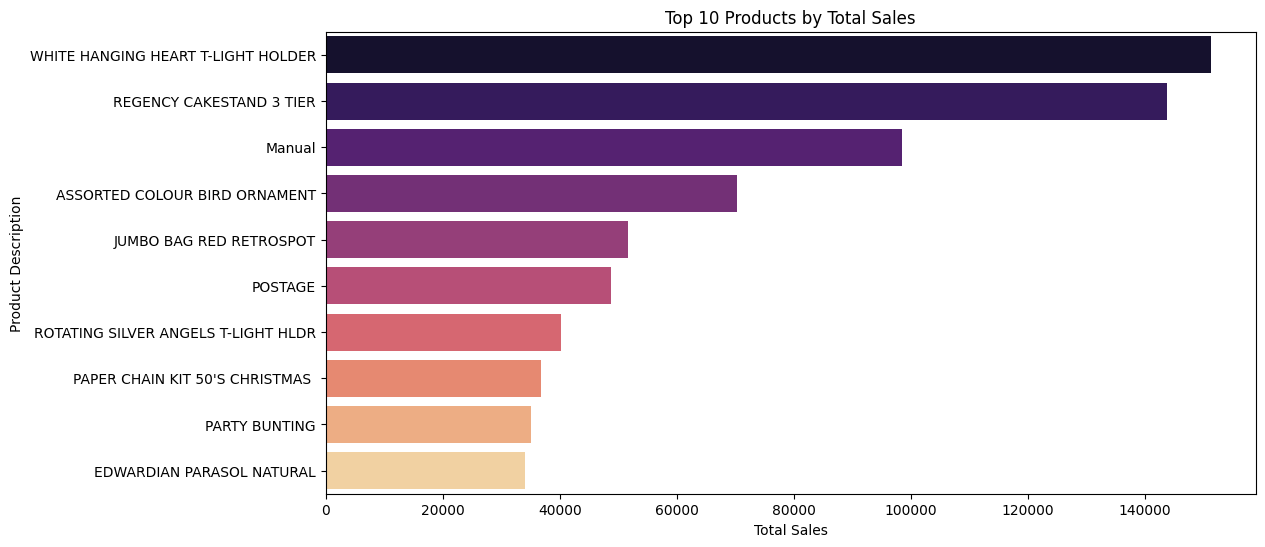

In [27]:
# Top 10 Countries by Total Sales
plt.figure(figsize=(12, 6))
top_countries_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_countries_sales.values, y=top_countries_sales.index, palette='viridis')
plt.title('Top 10 Countries by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Country')
plt.show()

# Top 10 Products by Total Sales
plt.figure(figsize=(12, 6))
top_products_sales = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products_sales.values, y=top_products_sales.index, palette='magma')
plt.title('Top 10 Products by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Description')
plt.show()

### Further Inspection of Categorical Features

Let's check the number of unique values in `StockCode`, `Description`, and `Country` to understand their cardinality.

In [28]:
print(f"Number of unique StockCodes: {df['StockCode'].nunique()}")
print(f"Number of unique Descriptions: {df['Description'].nunique()}")
print(f"Number of unique Countries: {df['Country'].nunique()}")

# Check for any StockCode that might have multiple descriptions
stock_desc_counts = df.groupby('StockCode')['Description'].nunique()
mult_desc_stockcodes = stock_desc_counts[stock_desc_counts > 1]

if not mult_desc_stockcodes.empty:
    print("\nStockCodes with multiple descriptions:")
    for stock_code in mult_desc_stockcodes.index[:5]: # Displaying first 5 if many
        print(f"- StockCode: {stock_code}")
        display(df[df['StockCode'] == stock_code]['Description'].unique())
else:
    print("\nNo StockCodes found with multiple descriptions.")

Number of unique StockCodes: 4017
Number of unique Descriptions: 4444
Number of unique Countries: 37

StockCodes with multiple descriptions:
- StockCode: 16011


array([' ANIMAL STICKERS', 'ANIMAL STICKERS'], dtype=object)

- StockCode: 16012


array(['FOOD/DRINK SPUNGE STICKERS', 'FOOD/DRINK SPONGE STICKERS'],
      dtype=object)

- StockCode: 20615


array(['BLUE SPOTTY PASSPORT COVER', 'BLUE POLKADOT PASSPORT COVER'],
      dtype=object)

- StockCode: 20652


array(['BLUE SPOTTY LUGGAGE TAG ', 'BLUE POLKADOT LUGGAGE TAG '],
      dtype=object)

- StockCode: 20658


array(['RED SPOTTY LUGGAGE TAG', 'RED RETROSPOT LUGGAGE TAG'],
      dtype=object)